In [1]:
#Importing nesessary library 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
data =pd.read_csv('C:/Users/shafqat Ali/Downloads/ifood_df.csv')

In [3]:
data.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [4]:
data.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married',
       'marital_Single', 'marital_Together', 'marital_Widow',
       'education_2n Cycle', 'education_Basic', 'education_Graduation',
       'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds',
       'AcceptedCmpOverall'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [6]:
data.isnull().sum()

Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds         0
AcceptedCmpO

In [7]:
data.duplicated().sum()

np.int64(184)

In [8]:
data.drop_duplicates(inplace=True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.nunique()

Income                  1963
Kidhome                    3
Teenhome                   3
Recency                  100
MntWines                 775
MntFruits                158
MntMeatProducts          551
MntFishProducts          182
MntSweetProducts         176
MntGoldProds             212
NumDealsPurchases         15
NumWebPurchases           15
NumCatalogPurchases       13
NumStorePurchases         14
NumWebVisitsMonth         16
AcceptedCmp3               2
AcceptedCmp4               2
AcceptedCmp5               2
AcceptedCmp1               2
AcceptedCmp2               2
Complain                   2
Z_CostContact              1
Z_Revenue                  1
Response                   2
Age                       56
Customer_Days            662
marital_Divorced           2
marital_Married            2
marital_Single             2
marital_Together           2
marital_Widow              2
education_2n Cycle         2
education_Basic            2
education_Graduation       2
education_Mast

In [11]:
#Columns Z_CostContact and Z_Revenue have all the same values. These columns will not help us to understand our customers better. We can drop these columns from the data frame.
data.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

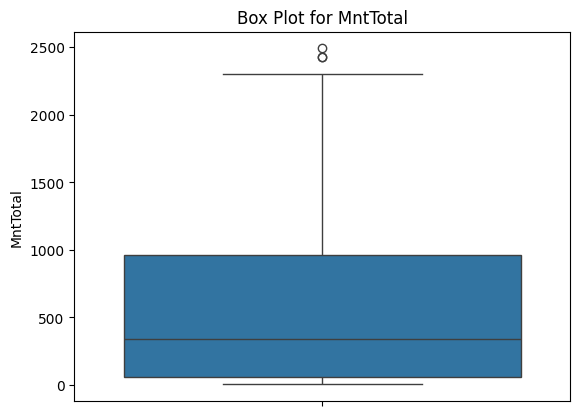

In [12]:
#Data Exploration
sns.boxplot(data=data, y='MntTotal')
plt.title('Box Plot for MntTotal')
plt.ylabel('MntTotal')
plt.show()


Handling Outliers
Calulate the first quartile (Q1) and the third quartile(Q3)

In [13]:

Q1 = data['MntTotal'].quantile(0.25)
Q3 = data['MntTotal'].quantile(0.75)
# calculate the Interquartile Range (IQR)
IQR = Q3 - Q1
# Define the lower and upper bounds for detecting outlieers
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = data[(data['MntTotal'] < lower_bound) | (data['MntTotal'] > upper_bound)]
outliers.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
1159,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1
1467,87679.0,0,0,62,1259,172,815,97,148,33,...,1,0,0,0,1,0,0,2491,2458,3
1547,90638.0,0,0,29,1156,120,915,94,144,96,...,0,0,0,0,0,1,0,2429,2333,1


In [14]:
data = data[(data['MntTotal'] > lower_bound) & (data['MntTotal'] < upper_bound)]

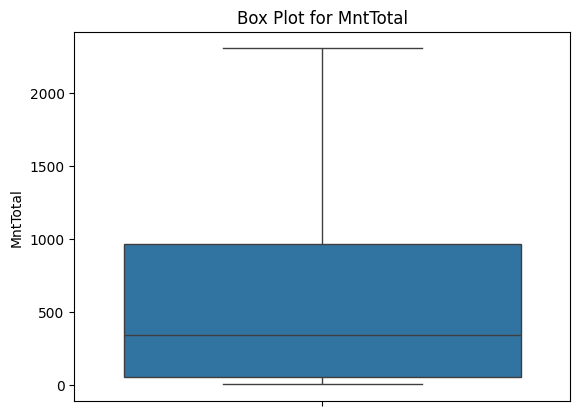

In [15]:
sns.boxplot(data=data, y='MntTotal')
plt.title('Box Plot for MntTotal')
plt.ylabel('MntTotal')
plt.show()


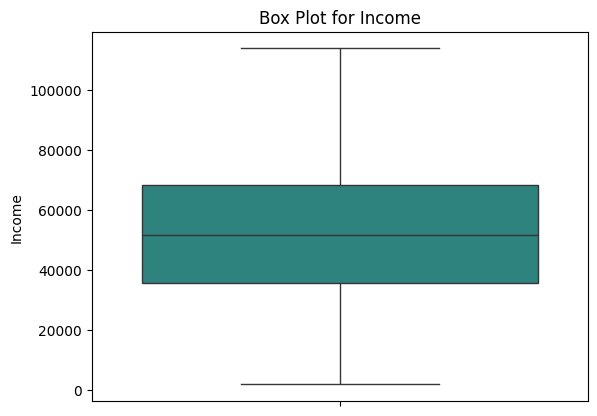

In [16]:
sns.boxplot(data=data, y='Income', palette='viridis')
plt.title('Box Plot for Income')
plt.ylabel('Income')
plt.show()

There is No outliers in income column

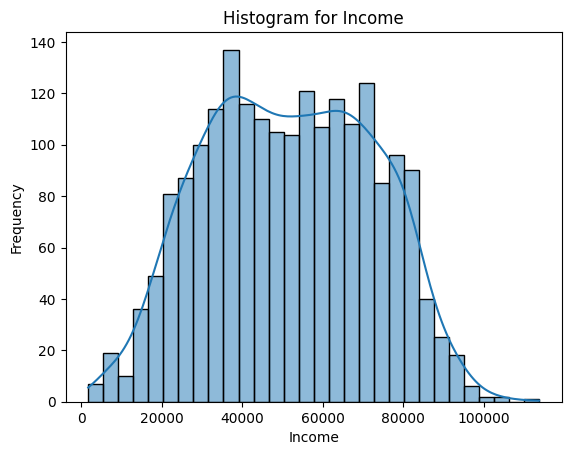

In [17]:
sns.histplot(data=data, x='Income', bins=30, kde=True)
plt.title('Histogram for Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [18]:
print("Skewness: %f" % data['Income'].skew())
print("Kurtosis: %f" % data['Income'].kurt())

Skewness: 0.003331
Kurtosis: -0.821945


the income distribution is nearly symmetrical, This means that income variability is more evenly spread without extreme highs or lows.


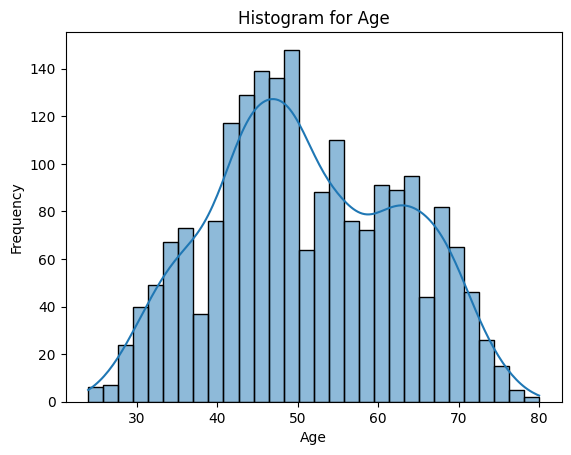

In [19]:
sns.histplot(data=data, x='Age', bins=30, kde=True)
plt.title('Histogram for Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [20]:
print("Skewness: %f" % data['Age'].skew())
print("Kurtosis: %f" % data['Age'].kurt())

Skewness: 0.093621
Kurtosis: -0.800800


The age distribution is nearly symmetrical. A platykurtic suggests fewer  extreme ages , customers are more spread across ages, groups rather than clustered around very  young or very old customers.

In [21]:

print("Skewness for NumDeal: %f" % data['NumDealsPurchases'].skew())
print("Kurtosis for NumDeal: %f" % data['NumDealsPurchases'].kurt())
print("Skewness for NumWeb: %f" % data['NumWebPurchases'].skew())
print("Kurtosis for NumWeb: %f" % data['NumWebPurchases'].kurt())
print("Skewness for NumCatalog: %f" % data['NumCatalogPurchases'].skew())
print("Kurtosis for NumCatalog: %f" % data['NumCatalogPurchases'].kurt())
print("Skewness for NumStore: %f" % data['NumStorePurchases'].skew())
print("Kurtosis for NumStore: %f" % data['NumStorePurchases'].kurt())
print("Skewness for NumWebVisits: %f" % data['NumWebVisitsMonth'].skew())
print("Kurtosis for NumWebVisits: %f" % data['NumWebVisitsMonth'].kurt())


Skewness for NumDeal: 2.332522
Kurtosis for NumDeal: 8.380951
Skewness for NumWeb: 1.236969
Kurtosis for NumWeb: 4.373395
Skewness for NumCatalog: 1.404432
Kurtosis for NumCatalog: 3.525634
Skewness for NumStore: 0.710530
Kurtosis for NumStore: -0.611787
Skewness for NumWebVisits: 0.280006
Kurtosis for NumWebVisits: 2.110991


- NumDeal has a high positive skewness (2.33) and extreme kurtosis (8.38), suggesting a strongly right-skewed distribution with heavy    tails—indicating occasional extreme values.
- NumWeb and NumCatalog also show right-skewed distributions with moderate kurtosis, meaning they have relatively frequent extreme values.
- NumStore has a slight positive skew (0.71) but a negative kurtosis (-0.61), indicating a flatter distribution with light tails—suggesting fewer extreme values.
- NumWebVisits is close to symmetric (0.28 skewness) with moderate kurtosis (2.11), implying a fairly normal distribution with mild tail weight.



In [22]:
#Correlation matrix
cols_demographics = ['Income','Age']
cols_children = ['Kidhome', 'Teenhome']
cols_marital = ['marital_Divorced', 'marital_Married','marital_Single', 'marital_Together', 'marital_Widow']
cols_mnt = ['MntTotal', 'MntRegularProds','MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_communication = ['Complain', 'Response', 'Customer_Days']
cols_campaigns = ['AcceptedCmpOverall', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
cols_source_of_purchase = ['NumDealsPurchases', 'NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
cols_education = ['education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD']

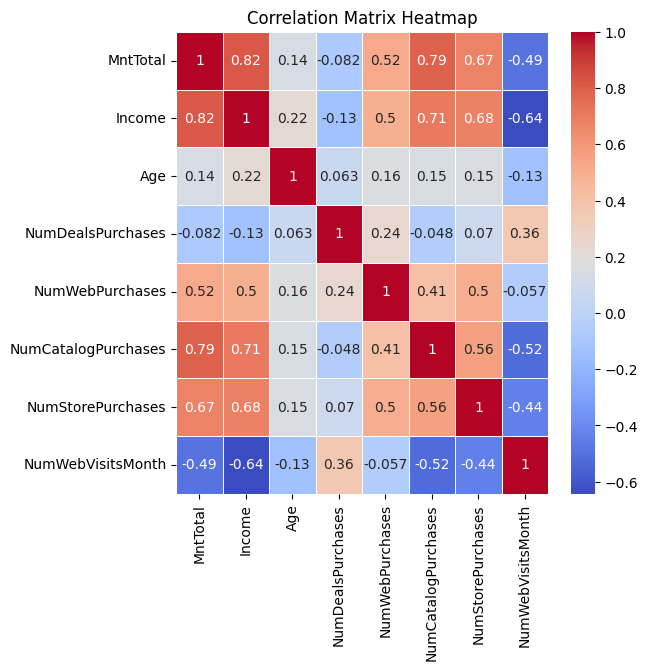

In [23]:
corr_matrix = data[['MntTotal']+cols_demographics+cols_source_of_purchase].corr()
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

- MntTotal has strongly positive relation with Income,NumStorePurchases,NumCatalogPurchases.
intermediate positive relation with NumWebPurchases,intermediate negative relation with NumWebVisitsMonth and weak negative relation with NumDealsPurchases.
- NumWebVisitsMonth has weak negative relation with NumWebPurchases.
- 


In [24]:
# Feature engineering
data['TotalPurchases'] = data['NumWebPurchases'] + data['NumCatalogPurchases'] + data['NumStorePurchases']
data['OnlinePurchaseRatio']= data['NumWebPurchases'] / (data['TotalPurchases'] + 1e-5)
data['MntFood'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + data['MntFishProducts'] + data['MntSweetProducts']
data['MntNonFood'] = data['MntGoldProds']
data['AvgSpendPerPurchase'] = data['MntTotal'] / (data['TotalPurchases'] + 1e-5)


In [25]:
# Feature engineering
def get_Purchases(row):
    if row['NumWebPurchases'] == 1:
        return 'WebPurchases'
    elif row['NumCatalogPurchases'] == 1:
        return 'CatalogPurchases'
    elif row['NumStorePurchases'] == 1:
        return 'StorePurchases'
    else:
        return 'DealsPurchases'
data['TotalPurchases'] = data.apply(get_Purchases, axis=1)

Text(0, 0.5, 'NumWebVisitsMonth')

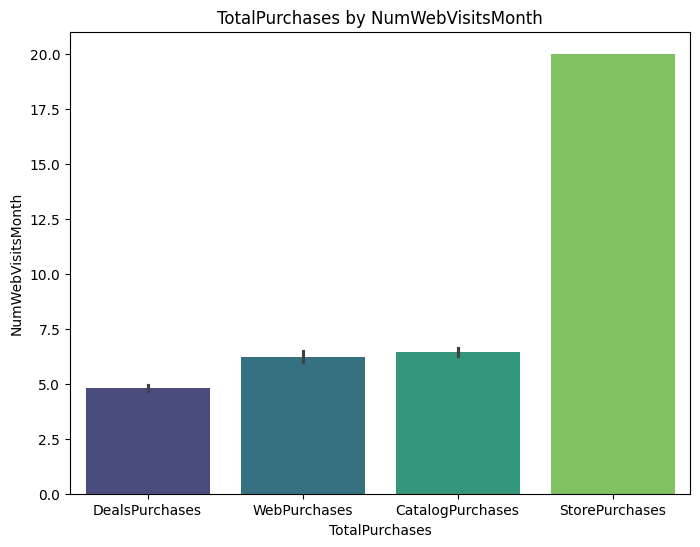

In [26]:
plt.figure(figsize=(8, 6))
sns.barplot(x='TotalPurchases', y='NumWebVisitsMonth', data=data, palette='viridis')
plt.title('TotalPurchases by NumWebVisitsMonth')
plt.xlabel('TotalPurchases')
plt.ylabel('NumWebVisitsMonth')

Text(0, 0.5, 'Age')

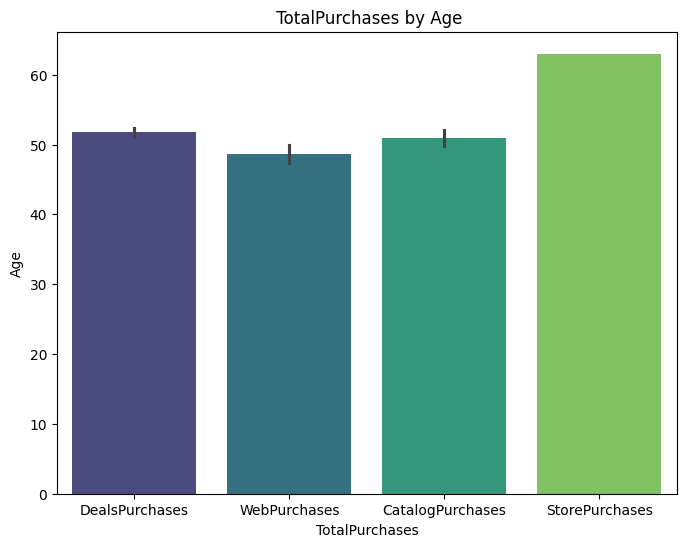

In [27]:

plt.figure(figsize=(8, 6))
sns.barplot(x='TotalPurchases', y='Age', data=data, palette='viridis')
plt.title(' TotalPurchases by Age')
plt.xlabel('TotalPurchases')
plt.ylabel('Age')



Text(0, 0.5, 'Income')

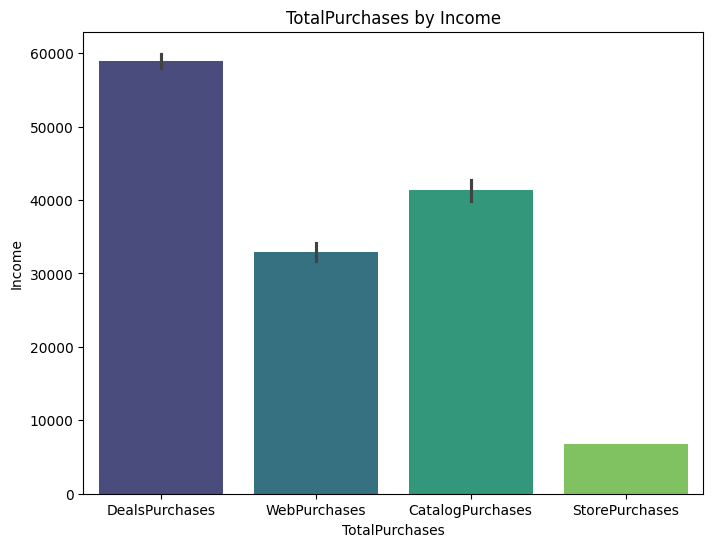

In [28]:
plt.figure(figsize=(8, 6))
sns.barplot(x='TotalPurchases', y='Income', data=data, palette='viridis')
plt.title('TotalPurchases by Income')
plt.xlabel('TotalPurchases')
plt.ylabel('Income')

In [29]:
# Selected features for clustering
features = [
    'Income', 'Age', 'MntTotal','Recency',
    'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'TotalPurchases', 'OnlinePurchaseRatio',
    'MntFood', 'MntNonFood', 'AvgSpendPerPurchase'
]


In [30]:
df_seg = data[features].dropna()


In [31]:
df_seg 

,Income,Age,MntTotal,Recency,NumDealsPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,TotalPurchases,OnlinePurchaseRatio,MntFood,MntNonFood,AvgSpendPerPurchase
0,58138.0,63,1529,58,3,10,4,7,DealsPurchases,0.363636,1529,88,69.499968
1,46344.0,66,21,38,2,1,2,5,WebPurchases,0.249999,21,6,5.249987
2,71613.0,55,734,26,1,2,10,4,DealsPurchases,0.400000,734,42,36.699982
3,26646.0,36,48,26,2,0,4,6,DealsPurchases,0.333333,48,5,7.999987
4,58293.0,39,407,94,5,3,6,5,DealsPurchases,0.357143,407,15,29.071408
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198,26816.0,34,19,50,1,0,3,4,DealsPurchases,0.000000,19,3,6.333312
2200,61223.0,53,1094,46,2,3,4,5,DealsPurchases,0.562500,1094,247,68.374957
2202,56981.0,39,1217,91,1,3,13,6,DealsPurchases,0.111111,1217,24,67.611074
2203,69245.0,64,782,8,2,5,10,3,DealsPurchases,0.285714,782,61,37.238078


K-Means Clustering

K-means clustering is an unsupervised machine learning algorithm used to cluster data based on similarity. K-means clustering usually works well in practice and scales well to the large datasets.

In this section:

- Standardising data
- Principal Component Analysis (PCA)
- Elbow method
- Silhouette score analysis

In [32]:
from sklearn.cluster import KMeans


Standardising data

K-means clustering algorithm is based on the calculation of distances between data points to form clusters. 
When features have different scales, features with larger scales can disproportionately influence the distance calculation. 
There are various ways to standardise features, we will use standard scaling .

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_seg  = [
   'Income', 'Age', 'MntTotal','Recency',
    'NumDealsPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'OnlinePurchaseRatio',
    'MntFood', 'MntNonFood', 'AvgSpendPerPurchase'
]

data_scaled = data.copy()
data_scaled[df_seg ]= scaler.fit_transform(data[df_seg ])


In [34]:
data_scaled[df_seg ]

,Income,Age,MntTotal,Recency,NumDealsPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,OnlinePurchaseRatio,MntFood,MntNonFood,AvgSpendPerPurchase
0,0.314791,1.017737,1.690991,0.314468,0.352869,2.634487,-0.558023,0.682740,0.266895,1.690991,0.853846,-0.041814
1,-0.255755,1.275363,-0.943282,-0.376211,-0.175387,-0.586703,-1.177605,-0.142519,-0.665311,-0.943282,-0.732927,-0.044142
2,0.966658,0.330735,0.302233,-0.790618,-0.703644,-0.228793,1.300723,-0.555148,0.565199,0.302233,-0.036295,-0.043002
3,-1.208666,-1.300895,-0.896117,-0.790618,-0.175387,-0.944613,-0.558023,0.270111,0.018305,-0.896117,-0.752278,-0.044042
4,0.322290,-1.043270,-0.268992,1.557689,1.409382,0.129117,0.061559,-0.142519,0.213626,-0.268992,-0.558769,-0.043279
...,...,...,...,...,...,...,...,...,...,...,...,...
2198,-1.200442,-1.472646,-0.946776,0.038196,-0.703644,-0.944613,-0.867814,-0.555148,-2.716149,-0.946776,-0.790979,-0.044103
2200,0.464031,0.158984,0.931104,-0.099940,-0.175387,0.129117,-0.558023,-0.142519,1.898247,0.931104,3.930637,-0.041855
2202,0.258820,-1.043270,1.145969,1.454088,-0.703644,0.129117,2.230095,0.270111,-1.804664,1.145969,-0.384611,-0.041882
2203,0.852104,1.103612,0.386082,-1.412229,-0.175387,0.844937,1.300723,-0.967777,-0.372329,0.386082,0.331372,-0.042983


In [35]:
data_scaled[df_seg ].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Income,2018.0,1.293976e-16,1.000248,-2.414003,-0.785424,-0.011142,0.798552,3.004305
Age,2018.0,1.584461e-17,1.000248,-2.331399,-0.699769,-0.098642,0.845986,2.477616
MntTotal,2018.0,-2.464717e-17,1.000248,-0.972979,-0.883889,-0.380791,0.700518,3.044811
Recency,2018.0,-9.506766e-17,1.000248,-1.688501,-0.859686,0.003662,0.867011,1.730359
NumDealsPurchases,2018.0,-2.640768e-17,1.000248,-1.231900,-0.703644,-0.175387,0.352869,6.691947
NumCatalogPurchases,2018.0,2.112615e-17,1.000248,-0.944613,-0.944613,-0.228793,0.487027,9.076867
NumStorePurchases,2018.0,-4.489306e-17,1.000248,-1.797186,-0.867814,-0.248232,0.681141,2.230095
NumWebVisitsMonth,2018.0,5.633639e-17,1.000248,-2.205665,-0.967777,0.270111,0.682740,6.046919
OnlinePurchaseRatio,2018.0,-1.760512e-16,1.000248,-2.716149,-0.665311,0.018300,0.565200,5.487224
MntFood,2018.0,-2.464717e-17,1.000248,-0.972979,-0.883889,-0.380791,0.700518,3.044811


The mean value for all colums is almost zero and the standard deviation is almost 1. All the data points were replaced by their z-scores.

Principal Component Analysis (PCA)
- PCA is a technique of dimensionality reduction. 
- PCA takes the original features (dimensions) and create new features that capture the most variance of the data.

In [36]:
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca_res = pca.fit_transform(data_scaled[df_seg])
data_scaled['pc1'] = pca_res[:,0]
data_scaled['pc2'] = pca_res[:,1]

In [37]:
X = data_scaled[df_seg ]
inertia_list = []
for K in range(2,10):
    inertia = KMeans(n_clusters=K, random_state=7).fit(X).inertia_
    inertia_list.append(inertia)

In [38]:
inertia_list

[16431.414989822882,
 14796.006459323038,
 13935.890225637031,
 13190.69703398063,
 11188.697833264952,
 10605.33331337565,
 10244.309331082026,
 9792.053915180692]

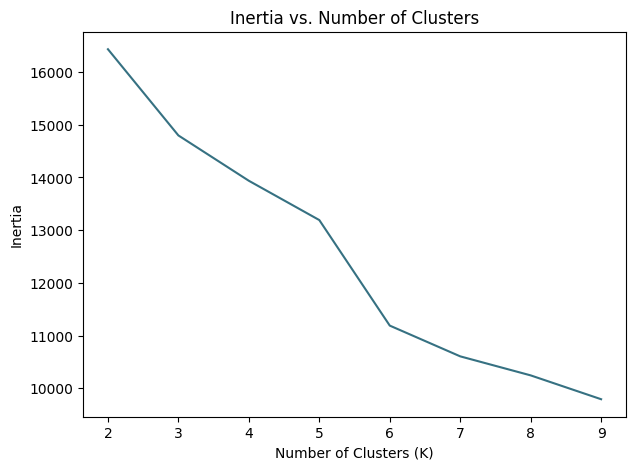

In [39]:
plt.figure(figsize=[7,5])
plt.plot(range(2,10), inertia_list, color=(54 / 255, 113 / 255, 130 / 255))
plt.title("Inertia vs. Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()


Elbow method suggests 4 or 5 clusters. Let's check silhouette score.



Silhouette score analysis
Silhouette score is a metric that used to assess the quality of clustering. 
A higher silhouette score indicates that the clusters are well-separated, while a lower score suggests that the clusters may overlap or are poorly defined.

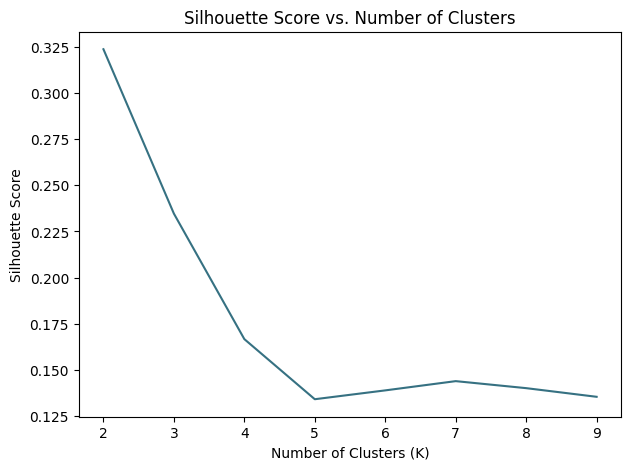

In [40]:
from sklearn.metrics import silhouette_score
silhouette_list = []
for K in range(2,10):
    model = KMeans(n_clusters = K, random_state=7)
    clusters = model.fit_predict(X)
    s_avg = silhouette_score(X, clusters)
    silhouette_list.append(s_avg)

plt.figure(figsize=[7,5])
plt.plot(range(2,10), silhouette_list, color=(54 / 255, 113 / 255, 130 / 255))
plt.title("Silhouette Score vs. Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

From the plot, the silhouette score appears to peak around k = 2 or 3 well-defined cluster.

In [41]:
model = KMeans(n_clusters=3, random_state = 7)
model.fit(data_scaled[df_seg ])
data_scaled['Cluster'] = model.predict(data_scaled[df_seg ])

Exploration of Clusters
- In this section:

- Visualisation of clusters
- Mean consumption of different product types by cluster
- Cluster sizes
- TotalPurchases by cluster
- OnlinePurchaseRatio feature by cluster
- Age by cluster
- AvgSpendPerPurchase by cluster

Visualisation of clusters


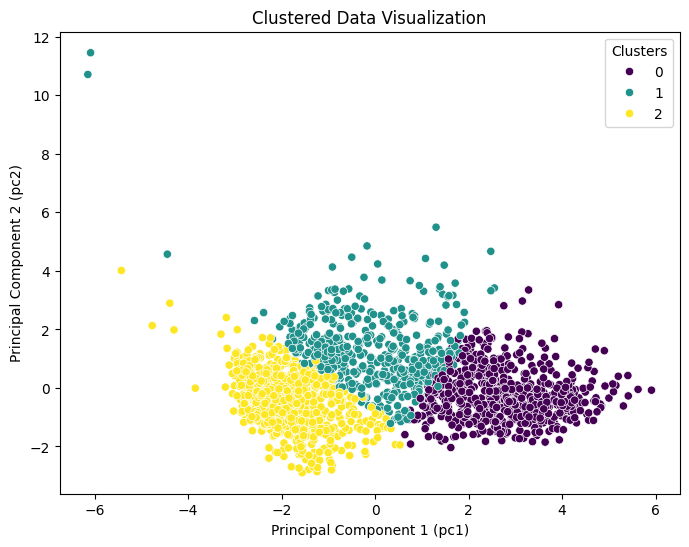

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pc1', y='pc2', data=data_scaled, hue='Cluster', palette='viridis')
plt.title('Clustered Data Visualization')
plt.xlabel('Principal Component 1 (pc1)')
plt.ylabel('Principal Component 2 (pc2)')
plt.legend(title='Clusters')

In [43]:
data['Cluster'] = data_scaled.Cluster
data.groupby('Cluster')[df_seg].mean()

,Income,Age,MntTotal,Recency,NumDealsPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,OnlinePurchaseRatio,MntFood,MntNonFood,AvgSpendPerPurchase
Cluster,,,,,,,,,,,,
0,74325.017323,52.601575,1248.615748,49.182677,1.497638,5.774803,8.629921,3.160630,0.267016,1248.615748,74.562205,66.204339
1,54023.153846,54.812890,558.139293,47.742204,4.293139,2.444906,6.941788,6.299376,0.402941,558.139293,58.045738,3152.831847
2,34378.572062,48.171840,78.417960,49.304878,1.873614,0.535477,3.201774,6.374723,0.337908,78.417960,14.716186,1009.319081


Mean consumption of different Purchases behavior by cluster


In [44]:
data['Cluster'] = data_scaled.Cluster
Purch_data = data.groupby('Cluster')[cols_source_of_purchase].mean().reset_index()
Purch_data.head()

,Cluster,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,1.497638,5.259843,5.774803,8.629921,3.160630
1,1,4.293139,6.457380,2.444906,6.941788,6.299376
2,2,1.873614,2.059867,0.535477,3.201774,6.374723


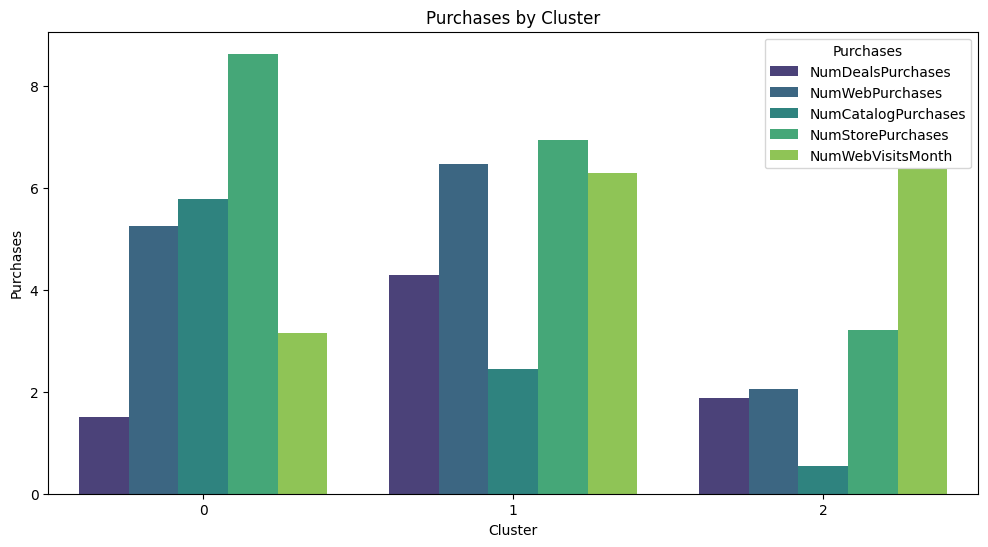

In [45]:
melted_data = pd.melt(Purch_data , id_vars="Cluster", var_name="Purchases", value_name="Type")
plt.figure(figsize=(12, 6))
sns.barplot(x="Cluster", y="Type", hue="Purchases", data=melted_data, ci=None, palette="viridis")
plt.title("Purchases by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Purchases")
plt.xticks(rotation=0)  
plt.legend(title="Purchases", loc="upper right")

plt.show()


cluster_sizes

Text(0, 0.5, 'TotalPurchases')

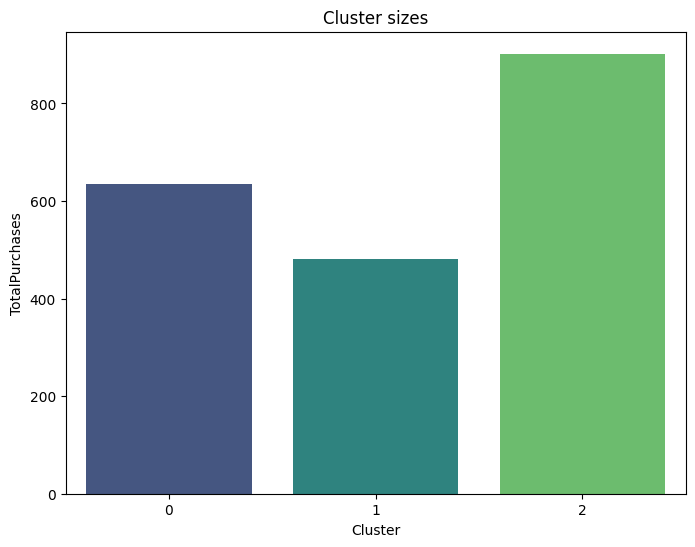

In [46]:
cluster_sizes = data.groupby('Cluster')[['TotalPurchases']].count().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Cluster', y='TotalPurchases', data=cluster_sizes, palette = 'viridis')
plt.title('Cluster sizes')
plt.xlabel('Cluster')
plt.ylabel('TotalPurchases')

In [47]:
total_rows = len(data)
cluster_sizes['Share%'] = round(cluster_sizes['TotalPurchases']/ total_rows*100,0)
cluster_sizes.head()

,Cluster,TotalPurchases,Share%
0,0,635,31.0
1,1,481,24.0
2,2,902,45.0


Age by cluster

Text(0, 0.5, 'Age')

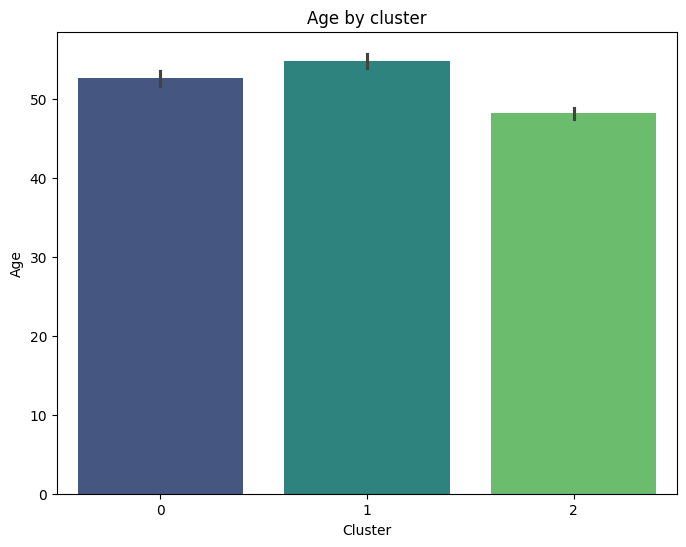

In [48]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='Age', data=data, palette='viridis')
plt.title('Age by cluster')
plt.xlabel('Cluster')
plt.ylabel('Age')

OnlinePurchaseRatio by Cluster


Text(0, 0.5, 'OnlinePurchaseRatio')

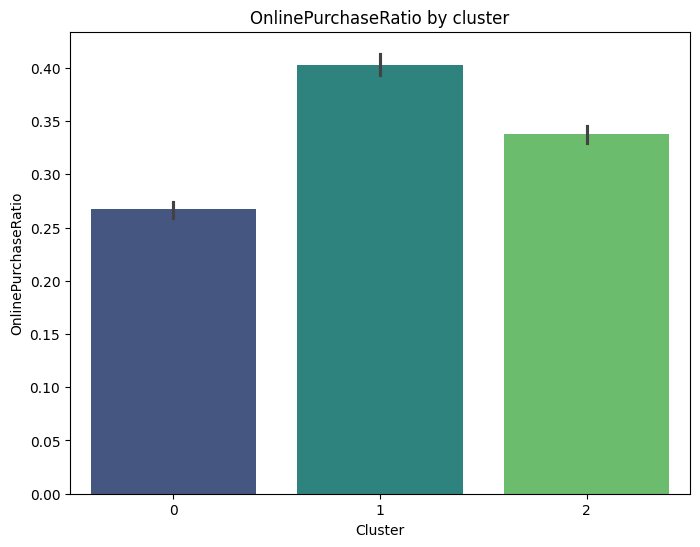

In [49]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='OnlinePurchaseRatio', data=data, palette='viridis')
plt.title('OnlinePurchaseRatio by cluster')
plt.xlabel('Cluster')
plt.ylabel('OnlinePurchaseRatio')

AvgSpendPerPurchase by cluster

Text(0, 0.5, 'AvgSpendPerPurchase')

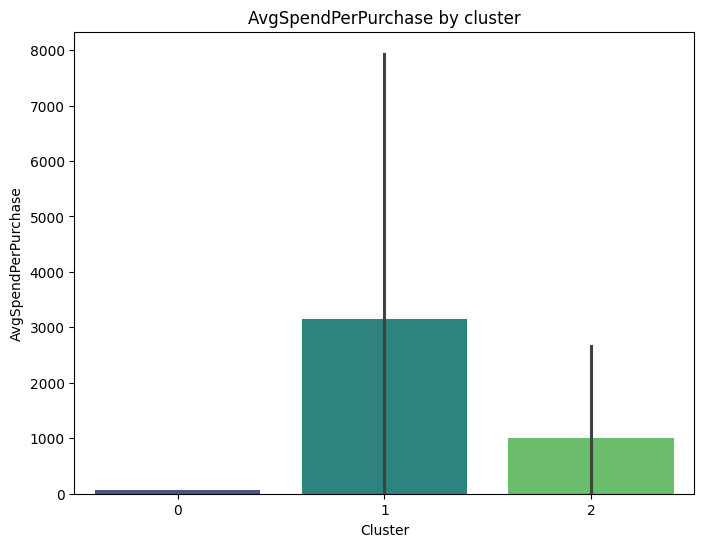

In [50]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Cluster', y='AvgSpendPerPurchase', data=data, palette='viridis')
plt.title('AvgSpendPerPurchase by cluster')
plt.xlabel('Cluster')
plt.ylabel('AvgSpendPerPurchase')

Results
- This section contains the results of the K-means clustering analysis, which aimed to identify distinct customer segments based on the total of purchases they made (TotalPurchases). 
- The analysis identify distinct customer segments based on behavioral, demographic, and transactional features.

Optimal number of clusters = 3
The Elbow Method and Silhouette Analysis suggested 3 clusters (k=3).
- The elbow method highlighted the number of 4 or 5 clusters as a reasonable number of clusters.
- The silhouette score analysis revealed a peak silhouette score for k=3.

Cluster Characteristics.

Cluster 0: 
- Prefers in-store purchases, low digital and transaction activity.
- Slightly younger profiles, possibly more exploratory or discount-driven.
- Lowest digital engagement—likely traditional or less responsive to online channels.
- Average Spend Per Purchase shows  Lowest across all metrics—needs intervention.

Cluster 1:
- High digital engagement and spending, leading in web and deal-based purchases.
- Leads in both web visits and online purchase ratio—digital-first consumers.
- Slightly younger profiles, possibly more exploratory or discount-driven.
- Highest spend per transaction—premium buyers.

Cluster 2:
- Higher average age—likely loyal and consistent buyers.
- Represents the bulk of total purchases (45%), with moderate activity but strong value.
- Balanced behavior, room to increase online activity.
- Moderate spend, high volume.

Recommendations:

Cluster 0 – Low Engagement Segment
- The target: Reactivate or convert to higher value.
- Recommendations:
- Launch in-store loyalty or bundle promotions.
- Use personalized offline communication and onboarding messages.
- Introduce introductory online offers to drive digital adoption.

Cluster 1 – High-Value Digital Shoppers
- The target: Retain and reward.
- Recommendations:
- Target with premium product launches and online exclusives.
- Offer tiered digital loyalty programs or VIP perks.

Cluster 2 – Core Growth Group
- The target: Maximize potential and encourage gradual upscaling.
- Recommendations:
- Promote personalized cross-sell bundles.
- Use behavioral nudges: email reminders, curated picks.
- Introduce tier-based rewards to boost average spend.

Thank you 






